In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import AutoMinorLocator
import os

In [2]:
# Define paths
base_dir_run1 = "/home/paul/Msci/dm_sets/run1_samples/"
base_dir_run3 = "/home/paul/Msci/dm_sets/run3_samples/"
signal_dir_run1 = "/home/paul/Msci/dm_sets/run1_signal/"
signal_dir_run3 = "/home/paul/Msci/dm_sets/run3_signal/"
data_dir = "/home/paul/Msci/dm_sets/run_data/"

run = "run3"

if run == "run1":
    run_flag = "Run 1"
    base_dir = base_dir_run1
    signal_dir = signal_dir_run1
    plot_dir = "/home/paul/Msci/plots/inference/binary/run1/"

else:
    run_flag = "Run 3"
    base_dir = base_dir_run3
    signal_dir = signal_dir_run3
    plot_dir = "/home/paul/Msci/plots/inference/binary/run3/"

show_data = True

In [3]:
# POT targets
target_pot_run1 = 2.384e+20
target_pot_run3 = 5.02e20

# POT background scalings
scalings_run1 = {
    "nu": 1.0 / 2.35e21,
    "dirt": 1.026 * 0.75 / 1.6e21,
    "beamoff": 0.98 * (6230439.0 / 9186361.390000)
}

scalings_run3 = {
    "nu": 1.0 / (1.993661e21),
    "dirt": 1.0 * 0.35 / 1.020e21,
    "beamoff": 0.98 * (10710362.0 / 34147459.925000)
}

# Signal scalings
meson_scalings = {"pi0": 11.7, "eta": 7.2}
correction_dic_a = {
    "pi0": {"0.05": 10.671},
    "eta": {"0.05": 9.387}
}
total_pot = {
    "run1_dt_ratio_0.6_ma_0.05_pi0": 1.594137e+23,
    "run1_dt_ratio_0.6_ma_0.05_eta": 6.491310e+23,
    "run3_dt_ratio_0.6_ma_0.05_pi0": 3.951992e+23,
    "run3_dt_ratio_0.6_ma_0.05_eta": 1.458703e+24,
}

if run == "run1":
    scalings = scalings_run1
    target_pot = target_pot_run1
else: 
    scalings = scalings_run3
    target_pot = target_pot_run3

In [4]:
# Uncertainties (fractional)
multisim_uncertainty = 0.2
detvars_uncertainty = 0.3
dirt_uncertainty = 0.5

In [5]:
# Load data
df_nu = pd.read_csv(base_dir + f"{run}_nu_overlay_merged_with_weights.csv").drop_duplicates()
df_dirt = pd.read_csv(base_dir + f"{run}_dirt_merged_with_weights.csv").drop_duplicates()

if run == "run1":
    df_offbeam = pd.read_csv(base_dir + "run1_offbeam_larcv_cropped_full_set_scores.csv").drop_duplicates()
else:
    df_offbeam = pd.read_csv(base_dir + "run3_offbeam_larcv_cropped_scores.csv").drop_duplicates()

df_sig_pi0 = pd.read_csv(signal_dir + f"{run}_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores.csv").drop_duplicates()
df_sig_eta = pd.read_csv(signal_dir + f"{run}_dt_ratio_0.6_ma_0.05_eta_larcv_cropped_scores.csv").drop_duplicates()

# Load beam-on data
df_data = pd.read_csv(data_dir + f"{run}_NuMI_beamon_larcv_cropped_full_set_scores.csv").drop_duplicates()

#print(len(df_data[df_data['signal_score'] >= 0]))
#print(len(df_data))

# Filter out values 
df_nu = df_nu[df_nu['signal_score'] >= 0]
df_dirt = df_dirt[df_dirt['signal_score'] >= 0]
df_offbeam = df_offbeam[df_offbeam['signal_score'] >= 0]
df_beamon = df_data[df_data['signal_score'] >= 0]
df_sig_pi0 = df_sig_pi0[df_sig_pi0['signal_score'] >= 0]
df_sig_eta = df_sig_eta[df_sig_eta['signal_score'] >= 0]

print(f"Loading {run} data...")
print(f"  Nu overlay events: {len(df_nu)}")
print(f"  Dirt events: {len(df_dirt)}")
print(f"  Beam-off events: {len(df_offbeam)}")
print(f"  Signal pi0 events: {len(df_sig_pi0)}")
print(f"  Signal eta events: {len(df_sig_eta)}")
print(f"  Beam-on data events: {len(df_data)}")

Loading run3 data...
  Nu overlay events: 11525
  Dirt events: 2412
  Beam-off events: 15437
  Signal pi0 events: 12085
  Signal eta events: 12863
  Beam-on data events: 7323


In [6]:
nu_fraction = len(df_nu)/len(df_nu[df_nu['signal_score']>= 0.])
dirt_fraction = len(df_dirt)/len(df_dirt[df_dirt['signal_score'] >= 0.])
beamoff_fraction = len(df_offbeam)/len(df_offbeam[df_offbeam['signal_score'] >= 0.])
beamon_fraction = len(df_beamon)/len(df_beamon[df_beamon['signal_score'] >= 0.])


sig_fraction_pi0 = len(df_sig_pi0)/len(df_sig_pi0[df_sig_pi0['signal_score']>=0.])
sig_fraction_eta = len(df_sig_eta)/len(df_sig_pi0[df_sig_eta['signal_score']>=0.])

nu_scaling = target_pot * scalings["nu"] * nu_fraction / beamon_fraction
dirt_scaling = target_pot * scalings["dirt"] * dirt_fraction / beamon_fraction
offbeam_scaling = scalings["beamoff"] * beamoff_fraction / beamon_fraction

sig_scale_pi0 = sig_fraction_pi0 * target_pot * meson_scalings["pi0"] * correction_dic_a["pi0"]["0.05"] / total_pot[f"{run}_dt_ratio_0.6_ma_0.05_pi0"]
sig_scale_eta = sig_fraction_eta * target_pot * meson_scalings["eta"] * correction_dic_a["eta"]["0.05"] / total_pot[f"{run}_dt_ratio_0.6_ma_0.05_eta"]

print(f"\nScaling factors for {run}:")
print(f"  Nu scaling: {nu_scaling:.6f}")
print(f"  Dirt scaling: {dirt_scaling:.6f}")
print(f"  Offbeam scaling: {offbeam_scaling:.6f}")
print(f"  Signal pi0 scaling: {sig_scale_pi0:.6f}")
print(f"  Signal eta scaling: {sig_scale_eta:.6f}")
print(f" Beam on fraction: {beamon_fraction:.12f}")


Scaling factors for run3:
  Nu scaling: 0.251798
  Dirt scaling: 0.172255
  Offbeam scaling: 0.307377
  Signal pi0 scaling: 0.158591
  Signal eta scaling: 0.024757
 Beam on fraction: 1.000000000000


/tmp/ipykernel_36426/1253896876.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sig_fraction_eta = len(df_sig_eta)/len(df_sig_pi0[df_sig_eta['signal_score']>=0.])


In [7]:
# Event weights from MC simulations
def MC_weight_branch(df):
    if 'ppfx_cv' in df.columns and 'weightSplineTimesTune' in df.columns:
        df['weight'] = df['ppfx_cv'] * df['weightSplineTimesTune']
    elif 'weight' not in df.columns:
        df['weight'] = 1.0

MC_weight_branch(df_nu)
MC_weight_branch(df_dirt)

df_offbeam['weight'] = 1.0
df_sig_pi0['weight'] = 1.0
df_sig_eta['weight'] = 1.0
df_data['weight'] = 1.0

In [8]:
# Generate histograms
my_custom_bins = np.linspace(0., 1., 15)
variable = 'signal_score'

# Signal - NO weights (just count events)
counts_sig_pi0, bins_sig = np.histogram(df_sig_pi0[variable], bins=my_custom_bins)
counts_sig_eta, _ = np.histogram(df_sig_eta[variable], bins=my_custom_bins)

# Backgrounds, nu and dirt weights
counts_nu, bins_nu = np.histogram(df_nu[variable], bins=my_custom_bins, weights=df_nu['weight'])
counts_dirt, bins_dirt = np.histogram(df_dirt[variable], bins=my_custom_bins, weights=df_dirt['weight'])
counts_offbeam, bins_offbeam = np.histogram(df_offbeam[variable], bins=my_custom_bins)

# Data NO weights
counts_data, bins_data = np.histogram(df_data[variable], bins=my_custom_bins)

# Apply scalings
counts_sig_pi0_scaled = counts_sig_pi0 * sig_scale_pi0
counts_sig_eta_scaled = counts_sig_eta * sig_scale_eta

counts_signal_scaled = counts_sig_pi0_scaled + counts_sig_eta_scaled
#counts_signal_scaled = counts_sig_pi0_scaled

counts_nu_scaled = counts_nu * nu_scaling
counts_dirt_scaled = counts_dirt * dirt_scaling
counts_offbeam_scaled = counts_offbeam * offbeam_scaling

In [9]:
# Calculate uncertainties
counts_bkg = counts_nu_scaled + counts_dirt_scaled + counts_offbeam_scaled

# Statistical uncertainties (sum of weights squared)
stats_nu = np.histogram(df_nu[variable], bins=my_custom_bins, weights=(df_nu['weight']*nu_scaling)**2)[0]
stats_dirt = np.histogram(df_dirt[variable], bins=my_custom_bins, weights=(df_dirt['weight']*dirt_scaling)**2)[0]
stats_beamoff = np.histogram(df_offbeam[variable], bins=my_custom_bins, weights=np.ones(len(df_offbeam))*offbeam_scaling**2)[0]

# Systematic uncertainties (fractional * central value)
sigma_detvar = counts_nu_scaled * detvars_uncertainty      # 30%
sigma_multisim = counts_nu_scaled * multisim_uncertainty   # 20%
sigma_mc_dirt = counts_dirt_scaled * dirt_uncertainty      # 50%

# Combine stat + syst for each component
sigma_nu = np.sqrt(stats_nu + sigma_detvar**2 + sigma_multisim**2)
sigma_dirt = np.sqrt(stats_dirt + sigma_mc_dirt**2)
sigma_beamoff = np.sqrt(stats_beamoff)

# Total error (add in quadrature)
total_error_mc = np.sqrt(sigma_nu**2 + sigma_dirt**2 + sigma_beamoff**2)

stats_up = counts_bkg + total_error_mc
stats_down = counts_bkg - total_error_mc

# Error band edges
bins_err = np.copy(bins_nu)
bins_err = np.append(bins_err, [bins_err[-1] + (bins_err[2] - bins_err[1])])
stats_up_plot = np.append(stats_up, [stats_up[-1], stats_up[-1]])
stats_down_plot = np.append(stats_down, [stats_down[-1], stats_down[-1]])

/tmp/ipykernel_36426/2049773787.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Saved: /home/paul/Msci/plots/inference/binary/run3//CNN_distribution_run3_with_data.png

Total Background: 7920.6
Total Data: 7281


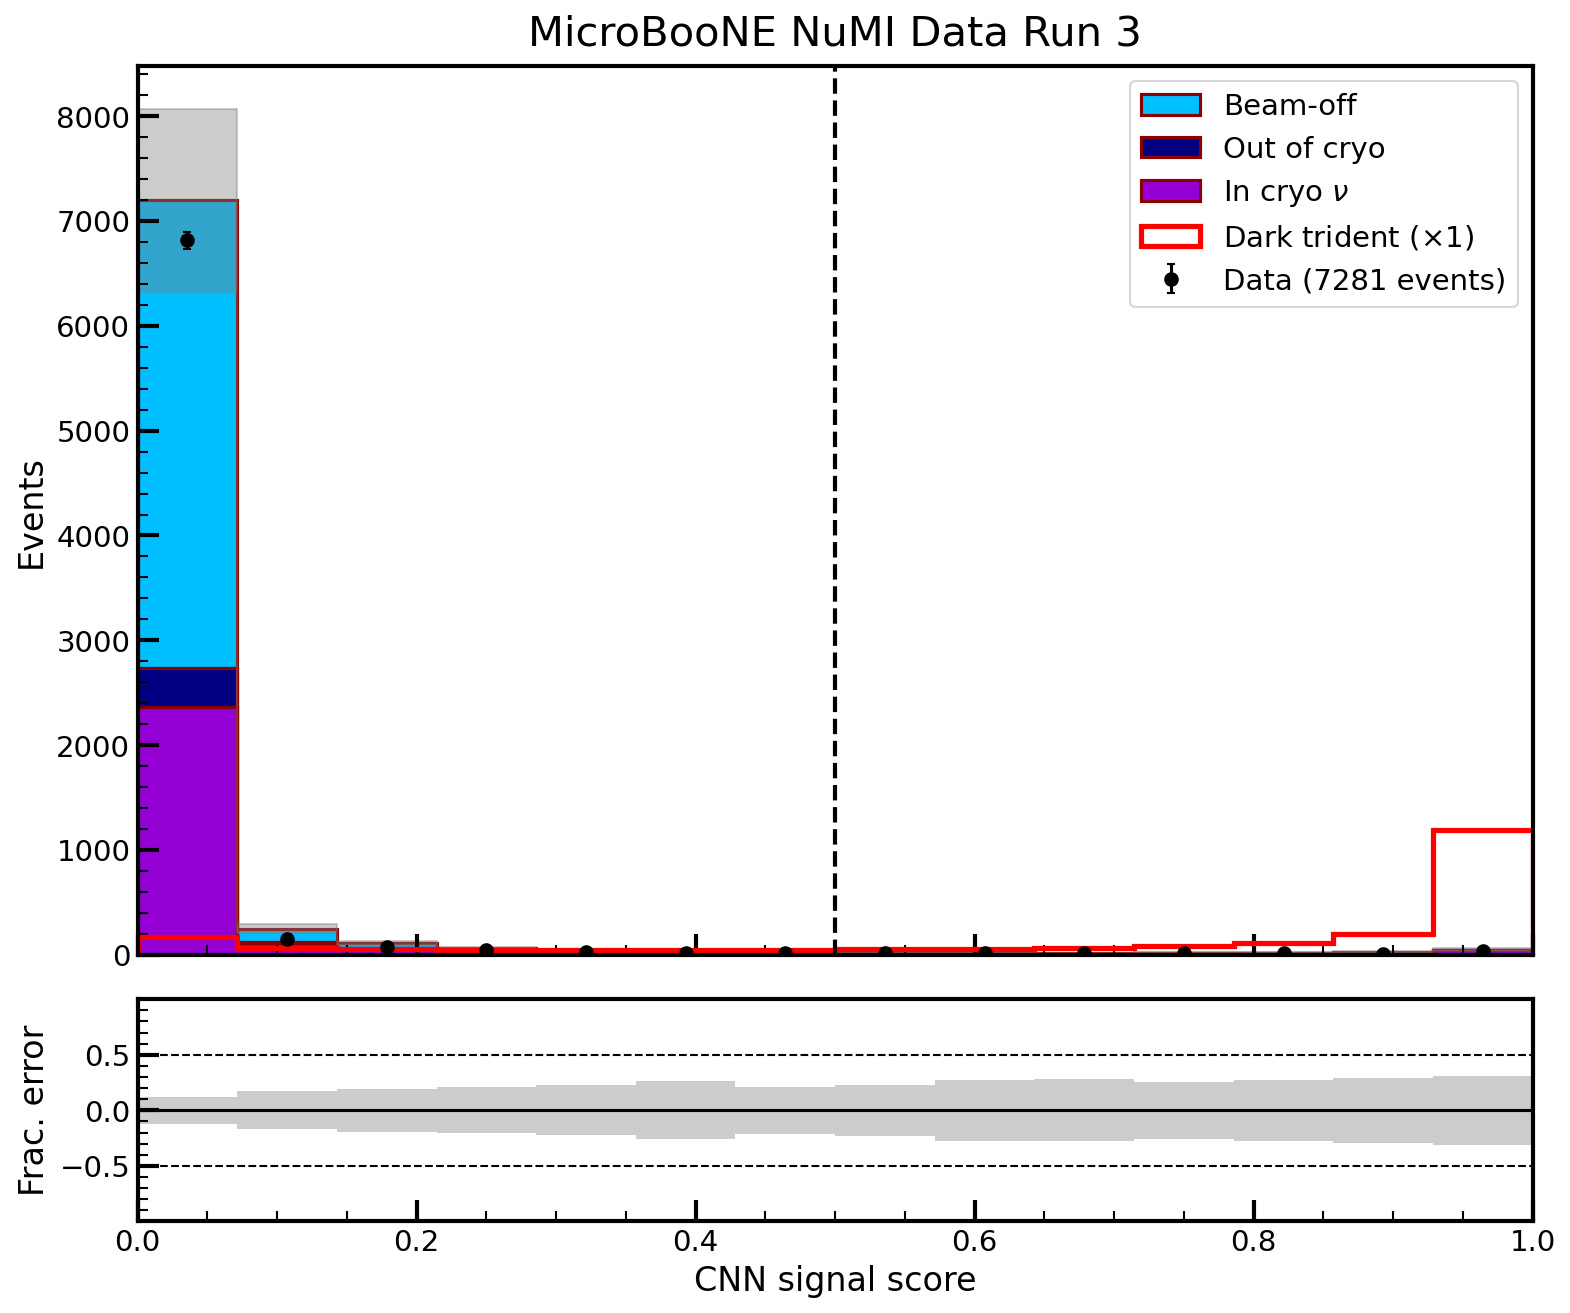

In [10]:
# Plot histograms
stacked_colors = ["darkviolet", "navy", "deepskyblue"]
stacked_legend = [r'In cryo $\nu$', r'Out of cryo', r'Beam-off']
stacked_bins = [bins_nu[:-1], bins_dirt[:-1], bins_offbeam[:-1]]
stacked_list = [counts_nu_scaled, counts_dirt_scaled, counts_offbeam_scaled]

# Create figure with ratio panel
fig, ax = plt.subplots(2, 1, figsize=(12, 10), dpi=150, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08})

# Formatting
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(2)
    ax[0].spines[axis].set_color('black')
    ax[1].spines[axis].set_linewidth(2)
    ax[1].spines[axis].set_color('black')

ax[0].xaxis.set_minor_locator(AutoMinorLocator())
ax[0].yaxis.set_minor_locator(AutoMinorLocator())
ax[1].xaxis.set_minor_locator(AutoMinorLocator())
ax[1].yaxis.set_minor_locator(AutoMinorLocator())

ax[0].set_title(r'MicroBooNE NuMI Data ' + run_flag, fontsize=20, pad=10)

# Stacked histogram for backgrounds
ax[0].hist(stacked_bins, bins=bins_nu, weights=stacked_list, histtype='stepfilled',
           stacked=True, color=stacked_colors, edgecolor="darkred", linewidth=1.5, label=stacked_legend)

# Error band
ax[0].fill_between(bins_err, stats_up_plot, stats_down_plot, color='gray', alpha=0.4, step='post')

# Data points 
if show_data:
    bin_centers = (my_custom_bins[:-1] + my_custom_bins[1:]) / 2
    ax[0].errorbar(bin_centers, counts_data, yerr=np.sqrt(counts_data), 
                   fmt='ko', markersize=6, capsize=2, label=f'Data ({int(np.sum(counts_data))} events)')

# Signal scaling
signal_display_scale = 1
ax[0].hist(bins_sig[:-1], bins=bins_sig, weights=counts_signal_scaled * signal_display_scale,
           histtype='step', label=rf'Dark trident ($\times${signal_display_scale})', 
           fill=False, edgecolor='red', linewidth=2.5)

# Signal 0.5 marker
ymax = ax[0].get_ylim()[1]
ax[0].axvline(0.5, color='black', linestyle='--', linewidth=2)

# Legend and labels
ax[0].legend(fontsize=14, loc='upper right')
ax[0].tick_params(axis="y", which='major', direction="in", length=10, width=2, labelsize=14)
ax[0].tick_params(axis="y", which='minor', direction="in", length=5, width=1)
ax[0].tick_params(axis="x", which='major', direction="in", length=10, width=2, labelbottom=False)
ax[0].tick_params(axis="x", which='minor', direction="in", length=5, width=1, labelbottom=False)
ax[0].set_xlim(0., 1.)
ax[0].set_ylabel("Events", fontsize=16)

# Frac error panel
frac_error = np.divide(total_error_mc, counts_bkg, where=counts_bkg > 0, 
                       out=np.zeros_like(total_error_mc))

ax[1].hist(bins_nu[:-1], bins=bins_nu, weights=frac_error, histtype='stepfilled', 
           color='gray', alpha=0.4, linewidth=1.5)
ax[1].hist(bins_nu[:-1], bins=bins_nu, weights=-frac_error, histtype='stepfilled', 
           color='gray', alpha=0.4, linewidth=1.5)
ax[1].axhline(0., color='black', linewidth=1.5)
ax[1].axhline(-0.5, color='black', linestyle='--', linewidth=1)
ax[1].axhline(0.5, color='black', linestyle='--', linewidth=1)

ax[1].tick_params(axis='both', which='major', direction="in", length=10, width=2, labelsize=14)
ax[1].tick_params(axis='both', which='minor', direction="in", length=5, width=1)
ax[1].set_yticks([-0.5, 0, 0.5])
ax[1].set_ylim(-1., 1.)
ax[1].set_xlim(0., 1.)
ax[1].set_xlabel(r'CNN signal score', fontsize=16)
ax[1].set_ylabel(r'Frac. error', fontsize=16)

plt.tight_layout()
plt.savefig(plot_dir + f"/CNN_distribution_{run}_with_data.png", bbox_inches="tight", dpi=150)
print(f"\nSaved: {plot_dir}/CNN_distribution_{run}_with_data.png")
print(f"\nTotal Background: {np.sum(counts_bkg):.1f}")
print(f"Total Data: {np.sum(counts_data)}")
plt.show()

In [11]:
# Signal region counts (>0.5)
data_sr = len(df_data[df_data['signal_score'] >= 0.5])

bkg_nu_sr = np.sum(df_nu[df_nu['signal_score'] >= 0.5]['weight']) * nu_scaling
bkg_dirt_sr = np.sum(df_dirt[df_dirt['signal_score'] >= 0.5]['weight']) * dirt_scaling  
bkg_offbeam_sr = len(df_offbeam[df_offbeam['signal_score'] >= 0.5]) * offbeam_scaling
bkg_total_sr = bkg_nu_sr + bkg_dirt_sr + bkg_offbeam_sr

print(f"Signal region (>0.5):")
print(f"  Data: {data_sr}")
print(f"  Background: {bkg_total_sr:.1f}")
print(f"  Data/Bkg: {data_sr/bkg_total_sr:.2f}")

Signal region (>0.5):
  Data: 127
  Background: 187.7
  Data/Bkg: 0.68


/tmp/ipykernel_36426/1667250257.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Total Data (SR): 127
Total Bkg (SR): 185.8
Data/Bkg: 0.68


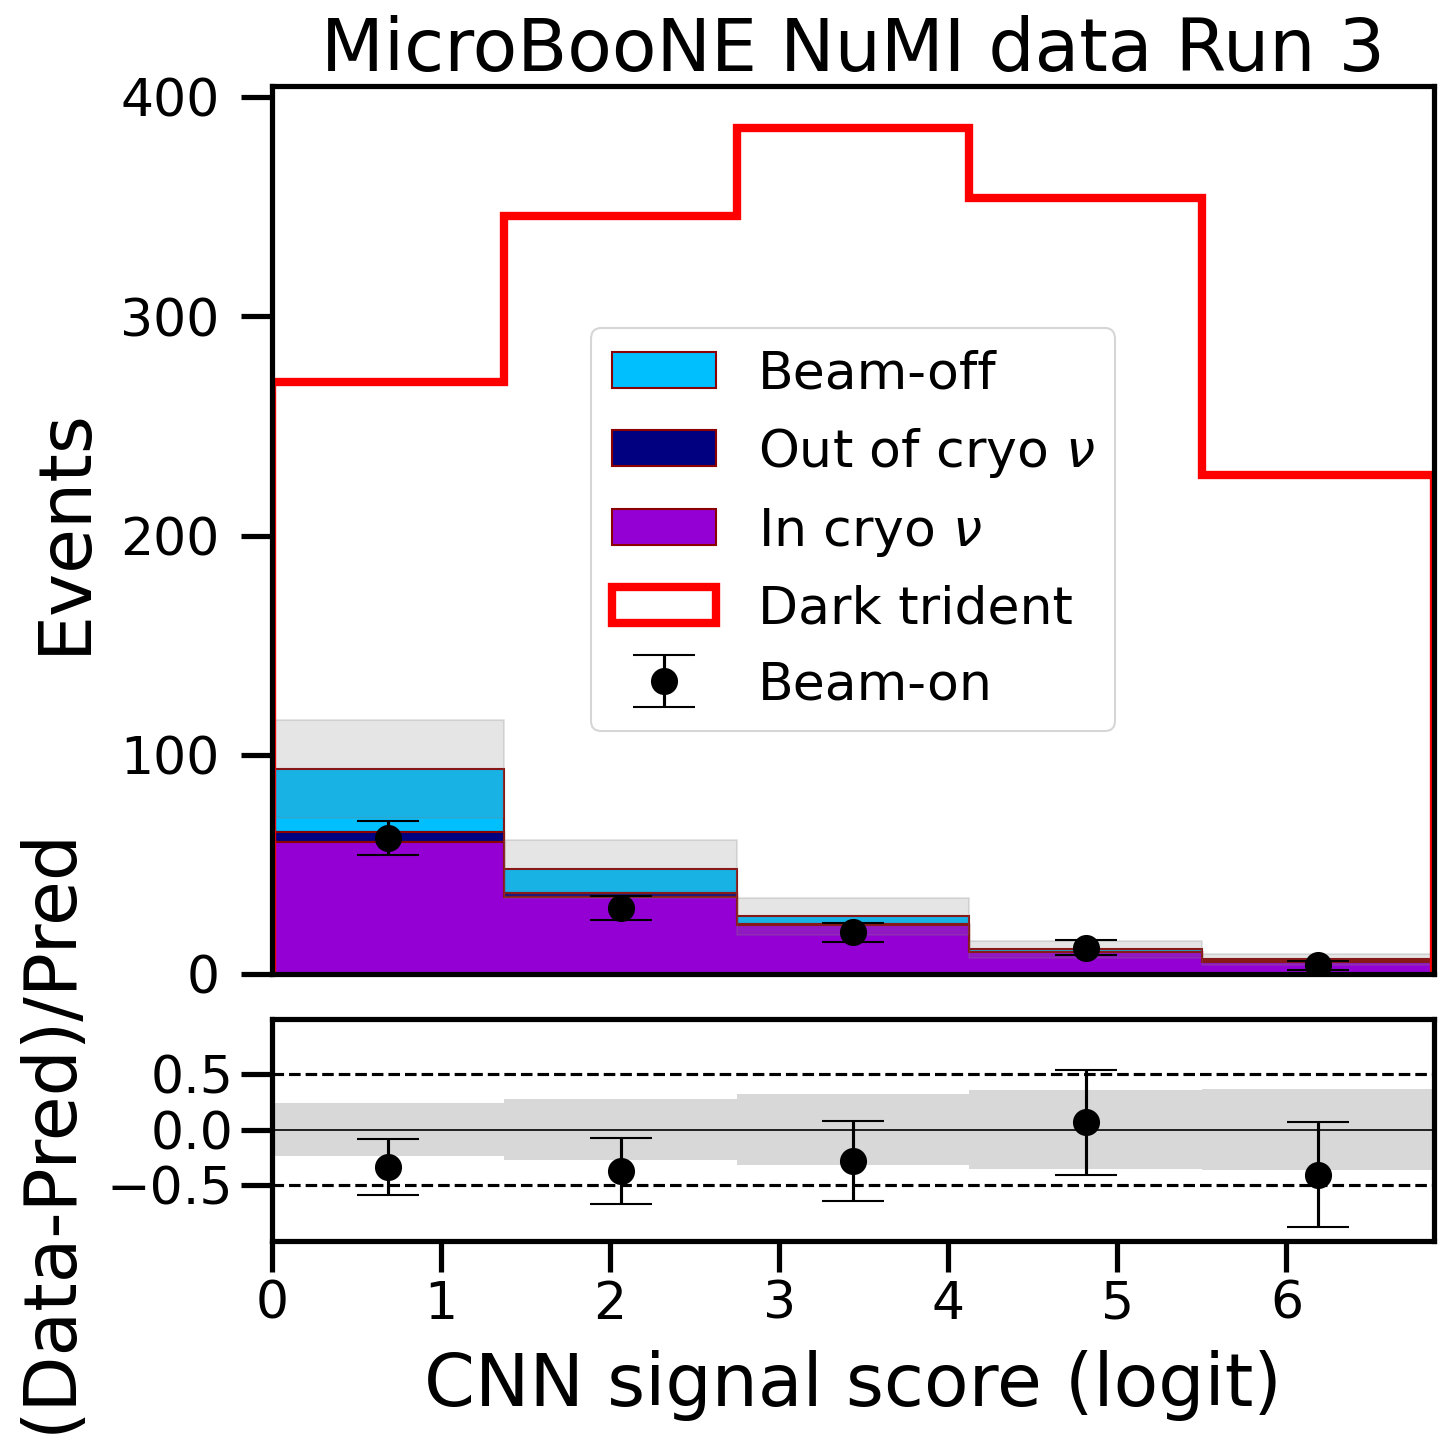

In [12]:
# Logit transformation 
def logit_transform(score):
    return np.log(score / (1 - score))

df_nu_plot = df_nu.copy()
df_dirt_plot = df_dirt.copy()
df_offbeam_plot = df_offbeam.copy()
df_data_plot = df_data.copy()
df_sig_pi0_plot = df_sig_pi0.copy()
df_sig_eta_plot = df_sig_eta.copy()

# Filter to signal region first (score >= 0.5)
df_nu_plot = df_nu_plot[df_nu_plot['signal_score'] >= 0.5]
df_dirt_plot = df_dirt_plot[df_dirt_plot['signal_score'] >= 0.5]
df_offbeam_plot = df_offbeam_plot[df_offbeam_plot['signal_score'] >= 0.5]
df_data_plot = df_data_plot[df_data_plot['signal_score'] >= 0.5]
df_sig_pi0_plot = df_sig_pi0_plot[df_sig_pi0_plot['signal_score'] >= 0.5]
df_sig_eta_plot = df_sig_eta_plot[df_sig_eta_plot['signal_score'] >= 0.5]

# Apply logit transform
df_nu_plot['signal_score'] = logit_transform(df_nu_plot['signal_score'])
df_dirt_plot['signal_score'] = logit_transform(df_dirt_plot['signal_score'])
df_offbeam_plot['signal_score'] = logit_transform(df_offbeam_plot['signal_score'])
df_data_plot['signal_score'] = logit_transform(df_data_plot['signal_score'])
df_sig_pi0_plot['signal_score'] = logit_transform(df_sig_pi0_plot['signal_score'])
df_sig_eta_plot['signal_score'] = logit_transform(df_sig_eta_plot['signal_score'])

# Bins (matching Luis)
my_custom_bins = [ 0., 1.375, 2.75, 4.125, 5.5, 6.875]
variable = 'signal_score'
up_plot = 6.875
down_plot = 0.

# Histograms
counts_nu_plot, bins_nu_plot = np.histogram(df_nu_plot[variable], bins=my_custom_bins, weights=df_nu_plot['weight'])
counts_dirt_plot, bins_dirt_plot = np.histogram(df_dirt_plot[variable], bins=my_custom_bins, weights=df_dirt_plot['weight'])
counts_offbeam_plot, bins_offbeam_plot = np.histogram(df_offbeam_plot[variable], bins=my_custom_bins)
counts_data_plot, bins_data_plot = np.histogram(df_data_plot[variable], bins=my_custom_bins)
counts_sig_pi0_plot, bins_sig_plot = np.histogram(df_sig_pi0_plot[variable], bins=my_custom_bins)
counts_sig_eta_plot, _ = np.histogram(df_sig_eta_plot[variable], bins=my_custom_bins)

# Apply scalings
counts_nu_scaled = counts_nu_plot * nu_scaling
counts_dirt_scaled = counts_dirt_plot * dirt_scaling
counts_offbeam_scaled = counts_offbeam_plot * offbeam_scaling
counts_sig_scaled = counts_sig_pi0_plot * sig_scale_pi0 + counts_sig_eta_plot * sig_scale_eta
#counts_sig_scaled = counts_sig_pi0_plot * sig_scale_pi0 

# Total background
counts_bkg_plot = counts_nu_scaled + counts_dirt_scaled + counts_offbeam_scaled

# # Legends with counts
# nu_legend = r'In cryo $\nu$ ({:.2f})'.format(np.sum(counts_nu_scaled))
# dirt_legend = r'Out of cryo $\nu$ ({:.2f})'.format(np.sum(counts_dirt_scaled))
# beamoff_legend = r'Beam-off ({:.2f})'.format(np.sum(counts_offbeam_scaled))
# beamon_legend = r'NuMI data ({:.0f})'.format(np.sum(counts_data_plot))
# dt_legend = r'Dark trident({:.2f})'.format(np.sum(counts_sig_scaled))

# Legends with counts
nu_legend = r'In cryo $\nu$'
dirt_legend = r'Out of cryo $\nu$'
beamoff_legend = r'Beam-off'
beamon_legend = r'Beam-on'
dt_legend = r'Dark trident'

stacked_colors = ["darkviolet", "navy", "deepskyblue"]
stacked_legend = [nu_legend, dirt_legend, beamoff_legend]
stacked_bins = [bins_nu_plot[:-1], bins_dirt_plot[:-1], bins_offbeam_plot[:-1]]
stacked_list = [counts_nu_scaled, counts_dirt_scaled, counts_offbeam_scaled]

# Error calculation
stats_nu_plot = np.histogram(df_nu_plot[variable], bins=my_custom_bins, weights=(df_nu_plot['weight']*nu_scaling)**2)[0]
stats_dirt_plot = np.histogram(df_dirt_plot[variable], bins=my_custom_bins, weights=(df_dirt_plot['weight']*dirt_scaling)**2)[0]
stats_offbeam_plot = np.histogram(df_offbeam_plot[variable], bins=my_custom_bins, weights=np.ones(len(df_offbeam_plot))*offbeam_scaling**2)[0]

# Systematic uncertainties (fractional * central value)
sigma_detvar = counts_nu_scaled * detvars_uncertainty      # 30%
sigma_multisim = counts_nu_scaled * multisim_uncertainty   # 20%
sigma_mc_dirt = counts_dirt_scaled * dirt_uncertainty      # 50%

# Combine stat + syst for each component
sigma_nu = np.sqrt(stats_nu_plot + sigma_detvar**2 + sigma_multisim**2)
sigma_dirt = np.sqrt(stats_dirt_plot + sigma_mc_dirt**2)
sigma_beamoff = np.sqrt(stats_offbeam_plot)

# Total error (add in quadrature)
total_error_mc = np.sqrt(sigma_nu**2 + sigma_dirt**2 + sigma_beamoff**2)

stats_up = counts_bkg_plot + total_error_mc
stats_down = counts_bkg_plot - total_error_mc

# Trick for error band
bins_err = np.copy(bins_nu_plot)
bins_err = np.append(bins_err, [bins_err[-1] + (bins_err[2] - bins_err[1])])
stats_up_plot = np.append(stats_up, [stats_up[-1], stats_up[-1]])
stats_down_plot = np.append(stats_down, [stats_down[-1], stats_down[-1]])

# Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 10), dpi=150, gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08})

for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(2.5)
    ax[0].spines[axis].set_color('black')
    ax[1].spines[axis].set_linewidth(2.5)
    ax[1].spines[axis].set_color('black')

if run == "run1":
    pot_label = r'$2.2\times10^{20}$ POT'
else:
    pot_label = r'$5.0\times10^{20}$ POT'

ax[0].set_title(r'MicroBooNE NuMI data ' + run_flag, fontsize=35)
ax[0].hist(stacked_bins, bins=bins_nu_plot, weights=stacked_list, histtype='stepfilled', stacked=True, 
           color=stacked_colors, edgecolor="darkred", label=stacked_legend)
ax[0].fill_between(bins_err, stats_up_plot, stats_down_plot, color='gray', alpha=0.2, step='post')
ax[0].errorbar(bins_data_plot[:-1] + 0.5*(bins_data_plot[1:] - bins_data_plot[:-1]), counts_data_plot, 
               yerr=np.sqrt(counts_data_plot), fmt='o', markersize=12, capsize=15, color='black', label=beamon_legend)
ax[0].hist(bins_sig_plot[:-1], bins=bins_sig_plot, weights=counts_sig_scaled, histtype='step', 
           label=dt_legend, fill=False, edgecolor='red', linewidth=4)
ax[0].legend(fontsize=25)
ax[0].tick_params(axis="y", which='major', direction="out", length=15, width=2.5, pad=10, labelsize=25)
ax[0].tick_params(axis="x", which='major', direction="out", length=15, width=2.5, pad=10, bottom=False, top=False, labelbottom=False)
ax[0].set_xlim(down_plot, up_plot)
ax[0].set_ylabel("Events", fontsize=35, labelpad=10)

# Bottom panel - (Data - Pred) / Pred
total_pred = counts_bkg_plot
ratio = (counts_data_plot - total_pred) / total_pred
ratio_err = np.sqrt(counts_data_plot + total_error_mc**2) / total_pred

ax[1].errorbar(bins_data_plot[:-1] + 0.5*(bins_data_plot[1:] - bins_data_plot[:-1]), ratio, 
               yerr=ratio_err, fmt='o', markersize=12, capsize=15, color='black')
ax[1].hist(bins_data_plot[:-1], bins=bins_data_plot, weights=total_error_mc/counts_bkg_plot, 
           histtype='stepfilled', color='gray', alpha=0.3, lw=2)
ax[1].hist(bins_data_plot[:-1], bins=bins_data_plot, weights=-1*total_error_mc/counts_bkg_plot, 
           histtype='stepfilled', color='gray', alpha=0.3, lw=2)
ax[1].hlines(0., down_plot, up_plot, color='black', linewidth=0.8)
ax[1].hlines(-0.5, down_plot, up_plot, color='black', linestyle="--", linewidth=1.5)
ax[1].hlines(0.5, down_plot, up_plot, color='black', linestyle="--", linewidth=1.5)
ax[1].tick_params(axis='both', which='major', direction="out", length=15, width=2.5, labelsize=25)
ax[1].set_yticks([-0.5, 0, 0.5])
ax[1].set_ylim(-1., 1.)
ax[1].set_xlim(down_plot, up_plot)
ax[1].set_xlabel(r'CNN signal score (logit)', fontsize=35, labelpad=10)
ax[1].set_ylabel(r'(Data-Pred)/Pred', fontsize=35, labelpad=10)

plt.tight_layout()
plt.savefig(plot_dir + f"/CNN_distribution_{run}_signal_region_logit.png", bbox_inches="tight", dpi=150)
print(f"\nTotal Data (SR): {np.sum(counts_data_plot):.0f}")
print(f"Total Bkg (SR): {np.sum(counts_bkg_plot):.1f}")
print(f"Data/Bkg: {np.sum(counts_data_plot)/np.sum(counts_bkg_plot):.2f}")
plt.show()

In [13]:
# Events at preselection level (no CNN cut, just valid scores >= 0)
# POT scaled

print(f"Events at preselection level - {run_flag}")
print(f"Target POT: {target_pot:.2e}")
print()

# Nu overlay (weighted and scaled)
nu_presel = np.sum(df_nu[df_nu['signal_score'] >= 0]['weight']) * nu_scaling
print(f"In cryo nu: {nu_presel:.1f}")

# Dirt (weighted and scaled)
dirt_presel = np.sum(df_dirt[df_dirt['signal_score'] >= 0]['weight']) * dirt_scaling
print(f"Out of cryo (dirt): {dirt_presel:.1f}")

# Beam-off (just count * scaling)
offbeam_presel = len(df_offbeam[df_offbeam['signal_score'] >= 0]) * offbeam_scaling
print(f"Beam-off: {offbeam_presel:.1f}")

# Total background
total_bkg_presel = nu_presel + dirt_presel + offbeam_presel
print(f"\nTotal background: {total_bkg_presel:.1f}")

# Data (no scaling)
data_presel = len(df_data[df_data['signal_score'] >= 0])
print(f"Data: {data_presel}")

Events at preselection level - Run 3
Target POT: 5.02e+20

In cryo nu: 2771.1
Out of cryo (dirt): 404.4
Beam-off: 4745.0

Total background: 7920.6
Data: 7281


In [14]:
# ============================================================
# DIAGNOSTIC: Data vs Background through the pipeline
# ============================================================

print("=" * 70)
print(f"DIAGNOSTIC REPORT — {run_flag}")
print("=" * 70)

# ---- 1. RAW EVENT COUNTS ----
print("\n[1] RAW EVENT COUNTS (after drop_duplicates, before any cuts)")
print(f"    Nu overlay:  {len(df_nu)}")
print(f"    Dirt:        {len(df_dirt)}")
print(f"    Beam-off:    {len(df_offbeam)}")
print(f"    Beam-on:     {len(df_data)}")

# ---- 2. AFTER score >= 0 FILTER ----
n_nu_valid = len(df_nu[df_nu['signal_score'] >= 0])
n_dirt_valid = len(df_dirt[df_dirt['signal_score'] >= 0])
n_offbeam_valid = len(df_offbeam[df_offbeam['signal_score'] >= 0])
n_data_valid = len(df_beamon)

print(f"\n[2] AFTER signal_score >= 0 FILTER")
print(f"    Nu overlay:  {n_nu_valid}  (cut {len(df_nu) - n_nu_valid})")
print(f"    Dirt:        {n_dirt_valid}  (cut {len(df_dirt) - n_dirt_valid})")
print(f"    Beam-off:    {n_offbeam_valid}  (cut {len(df_offbeam) - n_offbeam_valid})")
print(f"    Beam-on:     {n_data_valid}  (cut {len(df_data) - n_data_valid})")

# ---- 3. SCALING FACTORS ----
print(f"\n[3] SCALING FACTORS")
print(f"    Target POT:           {target_pot:.4e}")
print(f"    scalings['nu']:       {scalings['nu']:.6e}")
print(f"    scalings['dirt']:     {scalings['dirt']:.6e}")
print(f"    scalings['beamoff']:  {scalings['beamoff']:.6f}")
print(f"    nu_fraction:          {nu_fraction:.6f}")
print(f"    dirt_fraction:        {dirt_fraction:.6f}")
print(f"    beamoff_fraction:     {beamoff_fraction:.6f}")
print(f"    beamon_fraction:      {beamon_fraction:.6f}")
print(f"    Final nu_scaling:     {nu_scaling:.6f}")
print(f"    Final dirt_scaling:   {dirt_scaling:.6f}")
print(f"    Final offbeam_scaling:{offbeam_scaling:.6f}")

# ---- 4. UNSCALED COUNTS (weighted for MC, raw for data/beamoff) ----
print(f"\n[4] UNSCALED WEIGHTED TOTALS (score >= 0)")
nu_wsum = df_nu[df_nu['signal_score'] >= 0]['weight'].sum()
dirt_wsum = df_dirt[df_dirt['signal_score'] >= 0]['weight'].sum()
print(f"    Nu weighted sum:     {nu_wsum:.2f}")
print(f"    Dirt weighted sum:   {dirt_wsum:.2f}")
print(f"    Beam-off raw count:  {n_offbeam_valid}")
print(f"    Beam-on raw count:   {n_data_valid}")

# ---- 5. SCALED TOTALS ----
nu_total = nu_wsum * nu_scaling
dirt_total = dirt_wsum * dirt_scaling
offbeam_total = n_offbeam_valid * offbeam_scaling
bkg_total = nu_total + dirt_total + offbeam_total

print(f"\n[5] SCALED TOTALS (all scores >= 0)")
print(f"    Nu:       {nu_total:.2f}")
print(f"    Dirt:     {dirt_total:.2f}")
print(f"    Beam-off: {offbeam_total:.2f}")
print(f"    Total bkg:{bkg_total:.2f}")
print(f"    Data:     {n_data_valid}")
print(f"    Data/Bkg: {n_data_valid/bkg_total:.3f}")

# ---- 6. LINEAR HISTOGRAM BIN-BY-BIN ----
linear_bins = np.linspace(0., 1., 15)
h_nu_l, _ = np.histogram(df_nu[df_nu['signal_score'] >= 0]['signal_score'], bins=linear_bins, weights=df_nu[df_nu['signal_score'] >= 0]['weight'])
h_dirt_l, _ = np.histogram(df_dirt[df_dirt['signal_score'] >= 0]['signal_score'], bins=linear_bins, weights=df_dirt[df_dirt['signal_score'] >= 0]['weight'])
h_offbeam_l, _ = np.histogram(df_offbeam[df_offbeam['signal_score'] >= 0]['signal_score'], bins=linear_bins)
h_data_l, _ = np.histogram(df_beamon['signal_score'], bins=linear_bins)

h_nu_ls = h_nu_l * nu_scaling
h_dirt_ls = h_dirt_l * dirt_scaling
h_offbeam_ls = h_offbeam_l * offbeam_scaling
h_bkg_l = h_nu_ls + h_dirt_ls + h_offbeam_ls

print(f"\n[6] LINEAR HISTOGRAM (0 to 1, 14 bins) — SCALED")
print(f"    {'Bin':>14s}  {'Nu':>8s}  {'Dirt':>8s}  {'Beamoff':>8s}  {'Bkg':>8s}  {'Data':>6s}  {'D/B':>6s}")
for i in range(len(linear_bins) - 1):
    r = h_data_l[i] / h_bkg_l[i] if h_bkg_l[i] > 0 else 0
    print(f"    [{linear_bins[i]:.2f}-{linear_bins[i+1]:.2f}]  {h_nu_ls[i]:8.2f}  {h_dirt_ls[i]:8.2f}  {h_offbeam_ls[i]:8.2f}  {h_bkg_l[i]:8.2f}  {h_data_l[i]:6.0f}  {r:6.3f}")

print(f"    {'TOTAL':>14s}  {np.sum(h_nu_ls):8.2f}  {np.sum(h_dirt_ls):8.2f}  {np.sum(h_offbeam_ls):8.2f}  {np.sum(h_bkg_l):8.2f}  {np.sum(h_data_l):6.0f}  {np.sum(h_data_l)/np.sum(h_bkg_l):6.3f}")

# ---- 7. SIGNAL REGION (score >= 0.5) ----
sr_bkg = np.sum(h_bkg_l[7:])
sr_data = np.sum(h_data_l[7:])

print(f"\n[7] SIGNAL REGION SUMMARY (score >= 0.5)")
print(f"    Nu:       {np.sum(h_nu_ls[7:]):.2f}")
print(f"    Dirt:     {np.sum(h_dirt_ls[7:]):.2f}")
print(f"    Beam-off: {np.sum(h_offbeam_ls[7:]):.2f}")
print(f"    Total bkg:{sr_bkg:.2f}")
print(f"    Data:     {sr_data:.0f}")
print(f"    Data/Bkg: {sr_data/sr_bkg:.3f}")

# ---- 8. LOGIT HISTOGRAM ----
logit_bins = [0., 1.375, 2.75, 4.125, 5.5, 6.875]

df_nu_sr = df_nu[(df_nu['signal_score'] >= 0.5)].copy()
df_dirt_sr = df_dirt[(df_dirt['signal_score'] >= 0.5)].copy()
df_offbeam_sr = df_offbeam[(df_offbeam['signal_score'] >= 0.5)].copy()
df_data_sr = df_beamon[(df_beamon['signal_score'] >= 0.5)].copy()

df_nu_sr['logit'] = logit_transform(df_nu_sr['signal_score'])
df_dirt_sr['logit'] = logit_transform(df_dirt_sr['signal_score'])
df_offbeam_sr['logit'] = logit_transform(df_offbeam_sr['signal_score'])
df_data_sr['logit'] = logit_transform(df_data_sr['signal_score'])

h_nu_log, _ = np.histogram(df_nu_sr['logit'], bins=logit_bins, weights=df_nu_sr['weight'])
h_dirt_log, _ = np.histogram(df_dirt_sr['logit'], bins=logit_bins, weights=df_dirt_sr['weight'])
h_offbeam_log, _ = np.histogram(df_offbeam_sr['logit'], bins=logit_bins)
h_data_log, _ = np.histogram(df_data_sr['logit'], bins=logit_bins)

h_nu_logs = h_nu_log * nu_scaling
h_dirt_logs = h_dirt_log * dirt_scaling
h_offbeam_logs = h_offbeam_log * offbeam_scaling
h_bkg_log = h_nu_logs + h_dirt_logs + h_offbeam_logs

print(f"\n[8] LOGIT HISTOGRAM (signal region, 5 bins) — SCALED")
print(f"    {'Bin':>16s}  {'Nu':>8s}  {'Dirt':>8s}  {'Beamoff':>8s}  {'Bkg':>8s}  {'Data':>6s}  {'D/B':>6s}")
for i in range(len(logit_bins) - 1):
    r = h_data_log[i] / h_bkg_log[i] if h_bkg_log[i] > 0 else 0
    print(f"    [{logit_bins[i]:5.3f}-{logit_bins[i+1]:5.3f}]  {h_nu_logs[i]:8.2f}  {h_dirt_logs[i]:8.2f}  {h_offbeam_logs[i]:8.2f}  {h_bkg_log[i]:8.2f}  {h_data_log[i]:6.0f}  {r:6.3f}")

print(f"    {'TOTAL':>16s}  {np.sum(h_nu_logs):8.2f}  {np.sum(h_dirt_logs):8.2f}  {np.sum(h_offbeam_logs):8.2f}  {np.sum(h_bkg_log):8.2f}  {np.sum(h_data_log):6.0f}  {np.sum(h_data_log)/np.sum(h_bkg_log):6.3f}")

print(f"\n{'=' * 70}")
print("END DIAGNOSTIC REPORT")
print(f"{'=' * 70}")

DIAGNOSTIC REPORT — Run 3

[1] RAW EVENT COUNTS (after drop_duplicates, before any cuts)
    Nu overlay:  11525
    Dirt:        2412
    Beam-off:    15437
    Beam-on:     7323

[2] AFTER signal_score >= 0 FILTER
    Nu overlay:  11525  (cut 0)
    Dirt:        2412  (cut 0)
    Beam-off:    15437  (cut 0)
    Beam-on:     7281  (cut 42)

[3] SCALING FACTORS
    Target POT:           5.0200e+20
    scalings['nu']:       5.015898e-22
    scalings['dirt']:     3.431373e-22
    scalings['beamoff']:  0.307377
    nu_fraction:          1.000000
    dirt_fraction:        1.000000
    beamoff_fraction:     1.000000
    beamon_fraction:      1.000000
    Final nu_scaling:     0.251798
    Final dirt_scaling:   0.172255
    Final offbeam_scaling:0.307377

[4] UNSCALED WEIGHTED TOTALS (score >= 0)
    Nu weighted sum:     11005.40
    Dirt weighted sum:   2347.92
    Beam-off raw count:  15437
    Beam-on raw count:   7281

[5] SCALED TOTALS (all scores >= 0)
    Nu:       2771.14
    Dirt:   